5 dòng dữ liệu đầu tiên:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


/tmp/ipykernel_339/67016853.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender', data=df, palette='Set2')


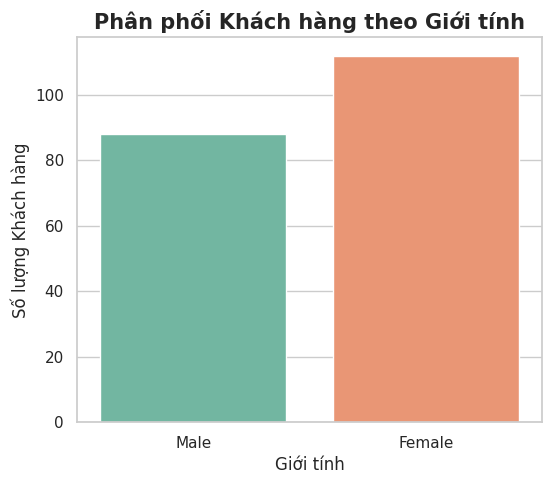

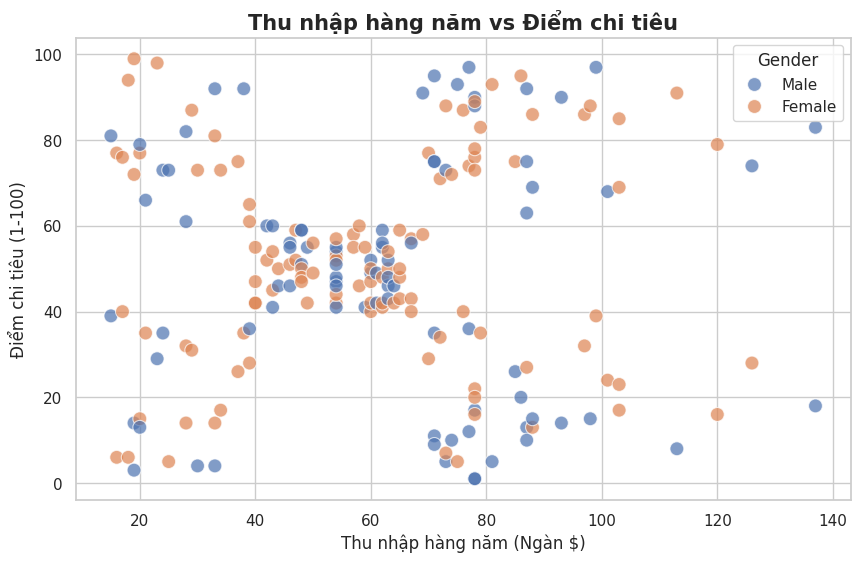

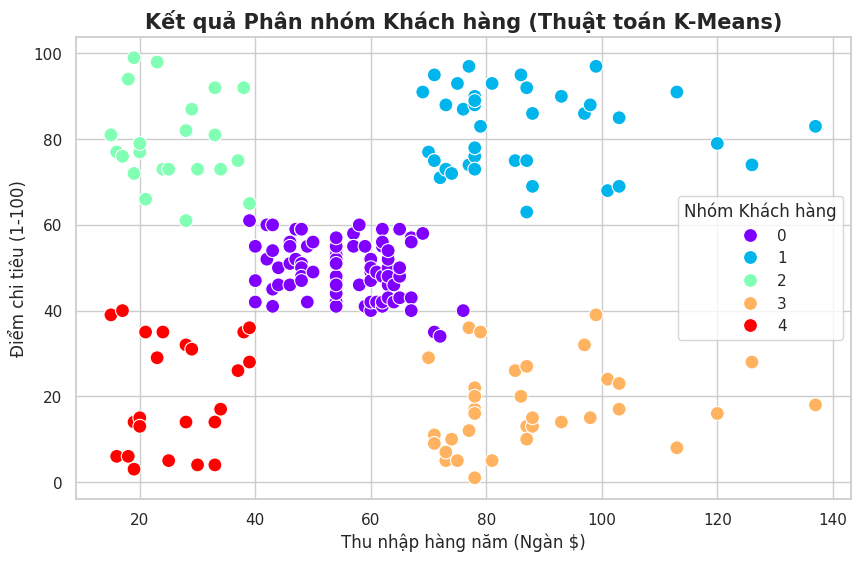


=> INSIGHT CỰC CHẤT:
- Nhóm 0: Thu nhập trung bình, chi tiêu trung bình (Khách hàng đại trà).
- Nhóm 1: Thu nhập cao, chi tiêu cao (Khách VIP - Cần chăm sóc kỹ).
- Nhóm 2: Thu nhập thấp, chi tiêu cao (Nhóm tiêu xài hoang phí).
- Nhóm 3: Thu nhập cao, chi tiêu thấp (Nhóm tiết kiệm - Cần có chiến dịch kích cầu).
- Nhóm 4: Thu nhập thấp, chi tiêu thấp (Nhóm ít tiềm năng).


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc file dữ liệu
df = pd.read_csv('Mall_Customers.csv')

print("5 dòng dữ liệu đầu tiên:")
display(df.head())
#Biểu đồ 1
plt.figure(figsize=(6, 5))
sns.countplot(x='Gender', data=df, palette='Set2')
plt.title('Phân phối Khách hàng theo Giới tính', fontsize=15, fontweight='bold')
plt.xlabel('Giới tính', fontsize=12)
plt.ylabel('Số lượng Khách hàng', fontsize=12)
plt.show()
# Biểu đồ 2
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Gender', data=df, s=100, alpha=0.7, palette='deep')
plt.title('Thu nhập hàng năm vs Điểm chi tiêu', fontsize=15, fontweight='bold')
plt.xlabel('Thu nhập hàng năm (Ngàn $)', fontsize=12)
plt.ylabel('Điểm chi tiêu (1-100)', fontsize=12)
plt.show()

# Biểu đồ 3 có kết hợp ML
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Cluster', data=df, palette='rainbow', s=100)
plt.title('Kết quả Phân nhóm Khách hàng (Thuật toán K-Means)', fontsize=15, fontweight='bold')
plt.xlabel('Thu nhập hàng năm (Ngàn $)', fontsize=12)
plt.ylabel('Điểm chi tiêu (1-100)', fontsize=12)
plt.legend(title='Nhóm Khách hàng')
plt.show()

print("\n=> INSIGHT CỰC CHẤT:")
print("- Nhóm 0: Thu nhập trung bình, chi tiêu trung bình (Khách hàng đại trà).")
print("- Nhóm 1: Thu nhập cao, chi tiêu cao (Khách VIP - Cần chăm sóc kỹ).")
print("- Nhóm 2: Thu nhập thấp, chi tiêu cao (Nhóm tiêu xài hoang phí).")
print("- Nhóm 3: Thu nhập cao, chi tiêu thấp (Nhóm tiết kiệm - Cần có chiến dịch kích cầu).")
print("- Nhóm 4: Thu nhập thấp, chi tiêu thấp (Nhóm ít tiềm năng).")